In [15]:
# ==============================================================
# 【AI 赛道】AI 应用说明
# AI 技术类型: LLM (CodeBuddy CLI)
# AI 参与环节: 因子构想生成、代码实现、自动调试
# ==============================================================
#
# factor_0045: Volume-Confirmed Intraday V-Recovery Signal
#
# 创意模式: mutation（基于 factor_0037 父代突变进化）
# 类别: 反转
# 数据源: 仅使用 bar1m (1分钟K线)
#
# 第一性原理:
#   原始 V-Recovery 信号捕捉的是"急跌→反弹"的日内价格模式。但并不是所有
#   V 形反弹都具有相同的预测能力——那些发生在低成交量环境下的反弹可能只是
#   随机波动（流动性噪声），而高成交量确认的反弹才代表真正的"聪明钱"进场。
#   本因子在原有 V-Recovery 信号上引入成交量确认机制：
#     1) 当日成交量相对于过去20日平均成交量的比率衡量交易"热度"
#     2) tanh 压缩确保成交量确认因子在 [0,1] 区间内
#     3) 成交量极低的日子（ratio << 1）信号被大幅削弱
#     4) 成交量高的日子（ratio > 1）信号基本保留
#   此外，将 drawdown 的 tanh 系数从 5 降至 3，避免极端下跌日单一主导因子。
#
# 突变改动 (vs factor_0037):
#   1. 成交量确认: 乘以 tanh(daily_volume / 20d_avg_volume)
#      → 深层逻辑: V 形反弹的可靠性与成交量成正比——机构资金介入时
#        成交量必然放大，低成交量反弹多为随机波动
#      → 这等价于给 V-Recovery 信号加了一个"可信度权重"
#   2. 缓和 drawdown 压缩: tanh(3 * drawdown) 替代 tanh(5 * drawdown)
#      → 深层逻辑: 原始 5x 系数让 drawdown > 0.3 时 tanh ≈ 1，失去了
#        对极端深幅和中等深幅的区分度。3x 系数在 drawdown ∈ [0, 0.6]
#        范围内保持更好的线性度，提高了中等深幅 V 形反转的区分度
#
# 最终公式:
#   volume_ratio      = daily_volume / 20d_avg_volume
#   volume_confirm    = tanh(volume_ratio)
#   drawdown          = (first_open - min_low) / first_open
#   recovery          = (last_close - min_low) / (max_high - min_low)
#   raw_factor        = -1.0 * tanh(3 * drawdown) * recovery^2 * volume_confirm
#   factor            = 截面 rank(raw_factor) → [0,1]
#
# 因子方向: 值越大 → 预测未来收益越高（rank 归一化后自动对齐）


def main(datasources, start_date, end_date):
    """
    因子构建主函数

    参数:
        datasources (dict): {"bar1m": "表名", "financial": "表名"}
        start_date (str): 开始时间
        end_date (str): 结束时间

    返回:
        pd.DataFrame: [date, instrument, factor]
    """
    import pandas as pd
    import numpy as np
    import dai

    # 1. 取数据源表名
    bar1m_table = datasources["bar1m"]

    # 2. 缓冲期（20日滚动均量需要 20 天缓冲）
    LOOKBACK_DAYS = 21
    query_start = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    # 3. DAI SQL: 计算日频聚合（drawdown, recovery, daily_volume）
    sql = f"""
    SELECT
        date::DATE::DATETIME AS date,
        instrument,
        (first(open ORDER BY date) - min(low)) / (first(open ORDER BY date) + 1e-10) AS drawdown,
        (last(close ORDER BY date) - min(low)) / (max(high) - min(low) + 1e-10) AS recovery,
        sum(volume) AS daily_volume
    FROM {bar1m_table}
    GROUP BY date::DATE, instrument
    ORDER BY date, instrument
    """

    agg_df = dai.query(
        sql, filters={'date': [query_start, end_date]}, compression=True
    ).df()

    # 将 decimal 列转为 float 避免运算类型错误
    for col in ['drawdown', 'recovery', 'daily_volume']:
        agg_df[col] = agg_df[col].astype(float)

    # 4. pandas 计算 20 日滚动平均成交量和最终 raw_factor
    agg_df = agg_df.sort_values(['instrument', 'date']).reset_index(drop=True)

    # 4a. 每只股票过去20日滚动平均成交量
    agg_df['avg_volume_20d'] = (
        agg_df.groupby('instrument')['daily_volume']
        .transform(lambda x: x.rolling(20, min_periods=1).mean())
    )

    # 4b. 计算 raw_factor（成交量确认增强）
    agg_df['raw_factor'] = (
        (-1.0)
        * np.tanh(3.0 * agg_df['drawdown'])
        * (agg_df['recovery'] ** 2)
        * np.tanh(agg_df['daily_volume'] / (agg_df['avg_volume_20d'] + 1e-10))
    )

    # 5. 截面归一化: 每日对 raw_factor 做 rank 归一到 [0,1]
    agg_df['factor'] = agg_df.groupby('date')['raw_factor'].rank(pct=True)

    # 6. 对齐中证1000成分股（只保留目标日期区间）
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    df = pd.merge(agg_df, stk_pool, how='inner', on=['date', 'instrument'])

    # 7. 处理极值和缺失值
    df['factor'] = df['factor'].replace([float('inf'), float('-inf')], None)
    df = df.dropna(subset=['factor'])

    return df[['date', 'instrument', 'factor']]


## 本地测试


[2026-07-19 08:53:08] [info     ] Factor computed                rows=1452626
[2026-07-19 08:53:08] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-19 08:53:19] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-19 08:53:20] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-19 08:53:21] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2019-01-02 至 2024-12-31
[2026-07-19 08:53:21] [info     ] ========== 数据检查 ==========
[2026-07-19 08:53:21] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', '

时段,IC
2020-02-03~2020-03-31,0.0058
2024-01-15~2024-02-08,0.0157
2024-09-24~2024-10-08,0.0204

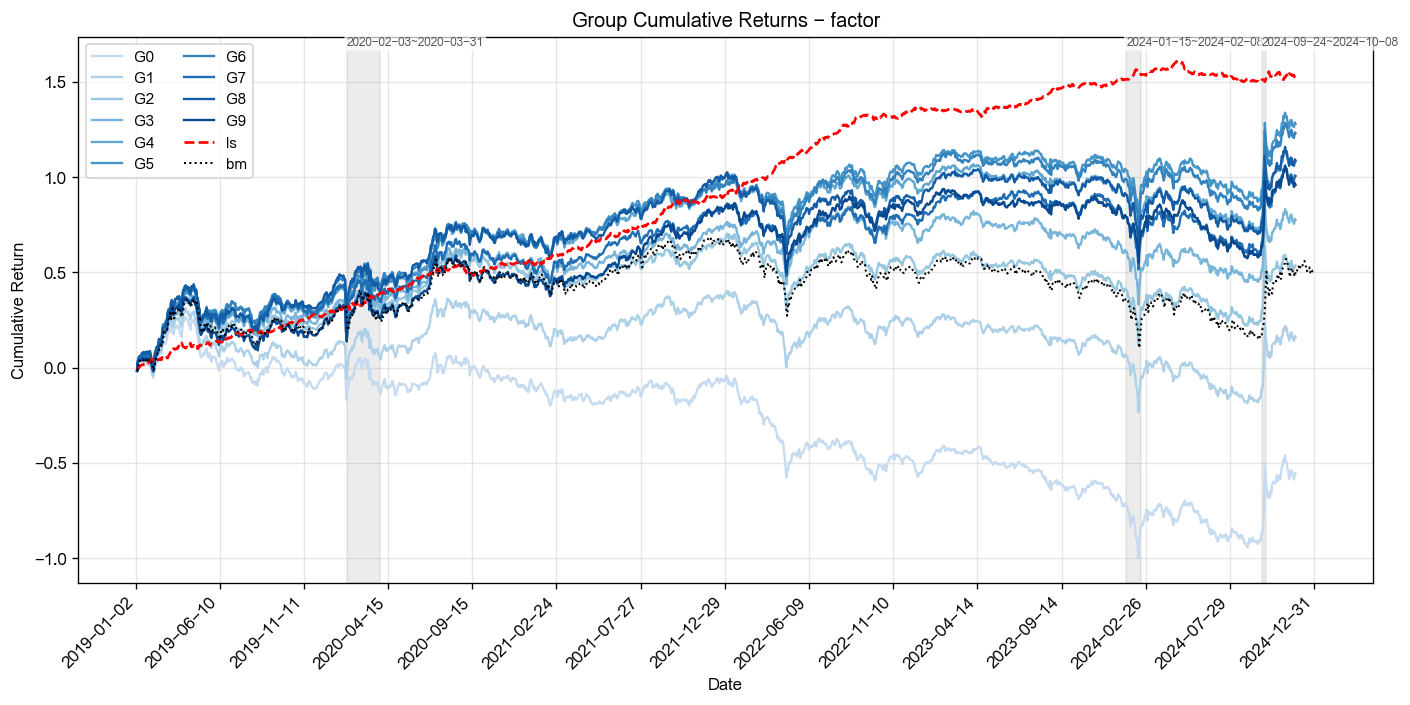
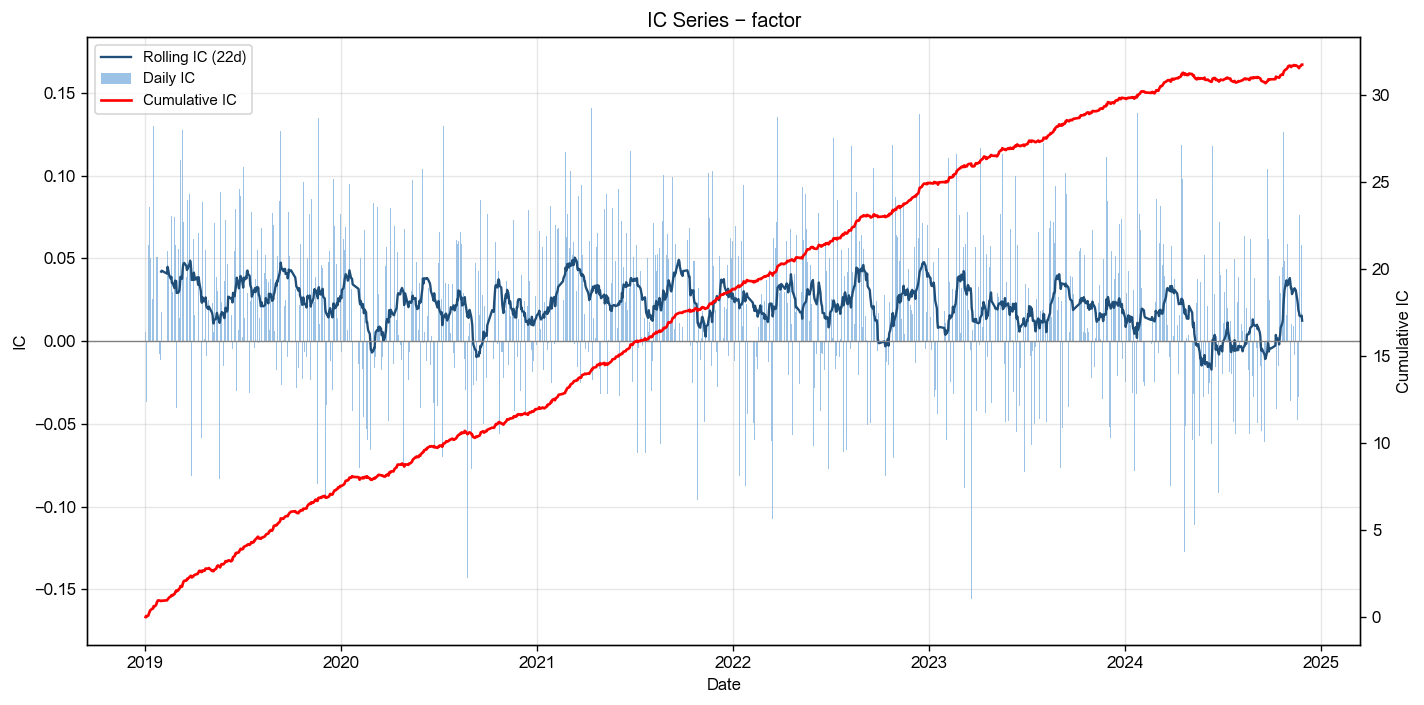
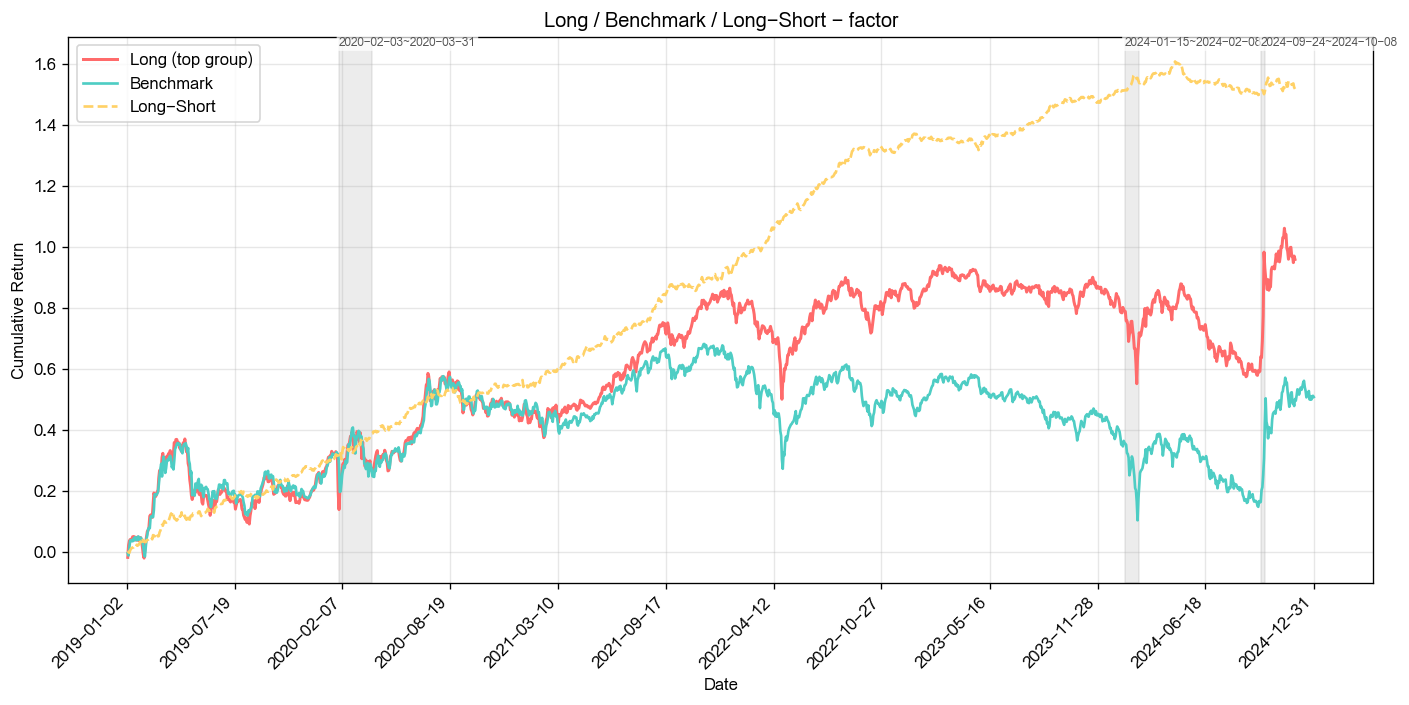
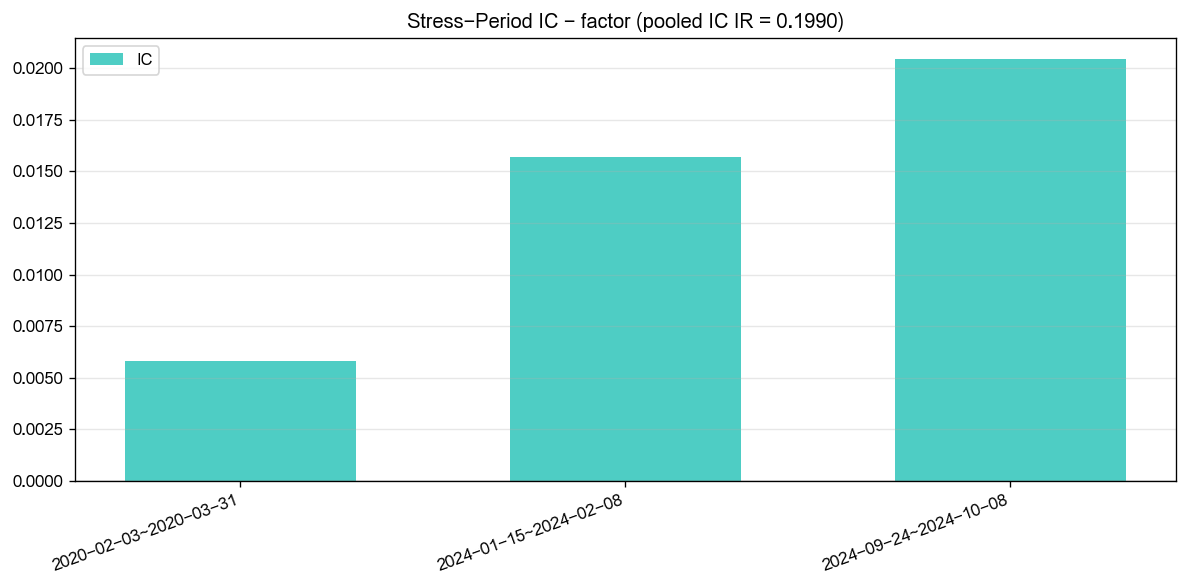
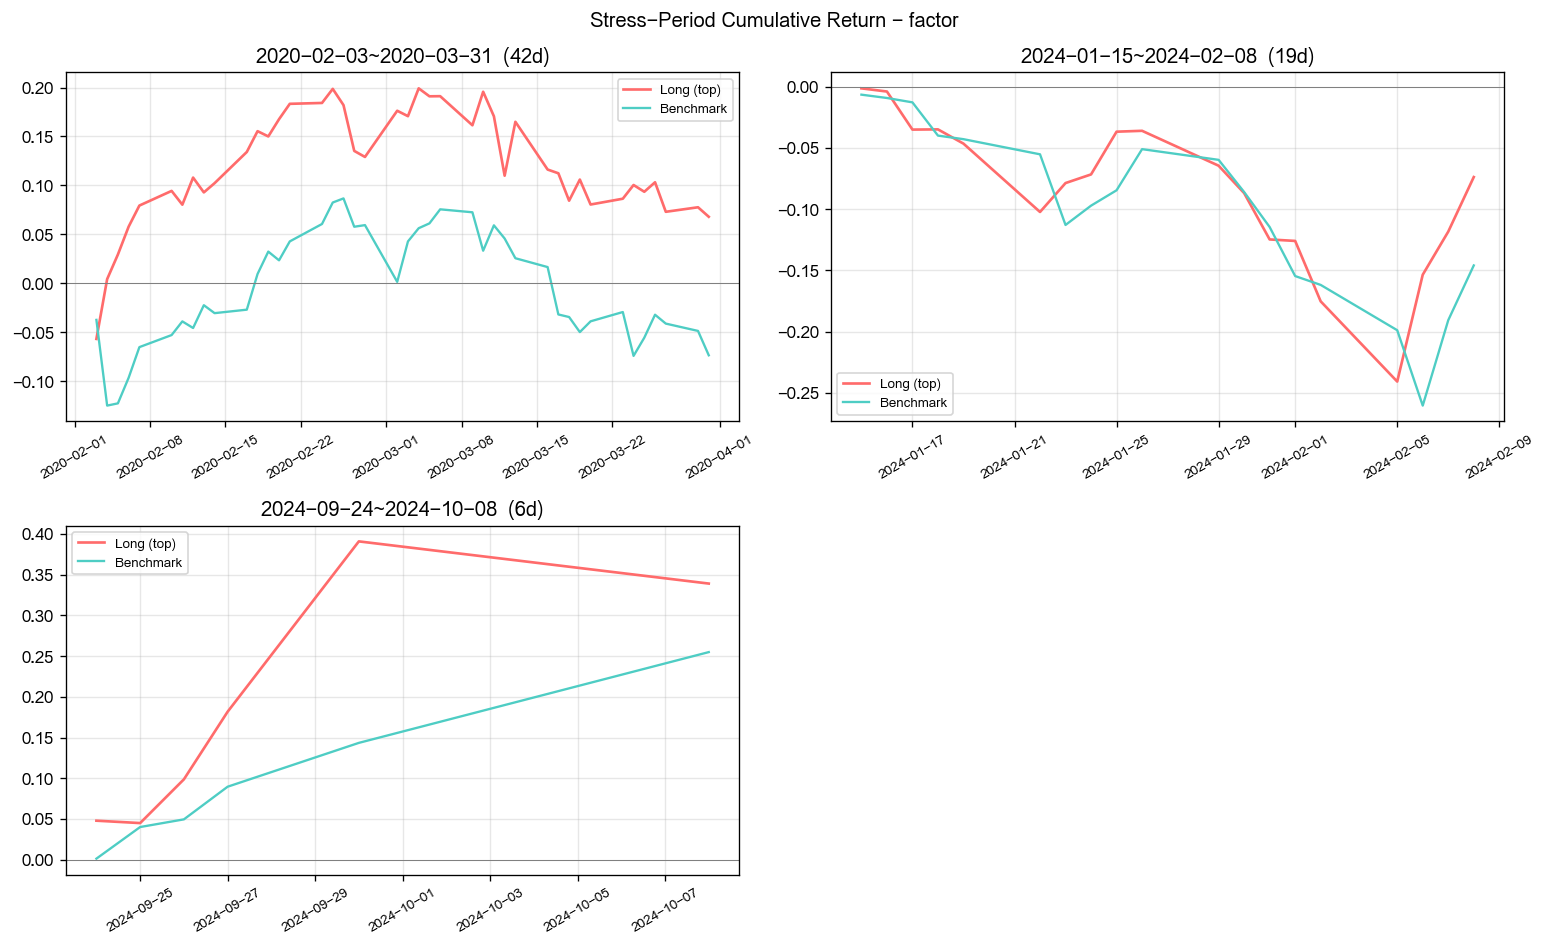

[2026-07-19 08:54:12] [info     ] ========== 因子池回归 ==========
[2026-07-19 08:54:13] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=2075 rows=2695583 start_date=2019-01-02
[2026-07-19 08:54:16] [info     ] 获取收益率数据, 耗时: 3.1333 秒
[2026-07-19 08:54:17] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.5219 秒
[2026-07-19 08:54:17] [info     ] 统计 回归结果, 耗时: 0.0065 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.6636,0.0241,0.0091,1.0000
2,beta_000300SH_22,1.5370,0.0176,0.0114,0.9857
3,turn,1.4504,0.0251,0.0173,0.9429
4,bias_20,1.3936,0.0296,0.0212,0.9286
5,list_days,1.3429,0.0104,0.0078,0.9714
6,momentum_5,1.3287,0.0175,0.0131,0.9429
7,net_profit_rate_ttm,1.2857,0.0066,0.0051,0.9286
8,ps_ttm,1.2690,0.0070,0.0055,0.9143
9,macd_hist_12_26_9,1.2619,0.0076,0.0060,0.9714
10,reversal_5,1.2589,0.0092,0.0073,0.9429

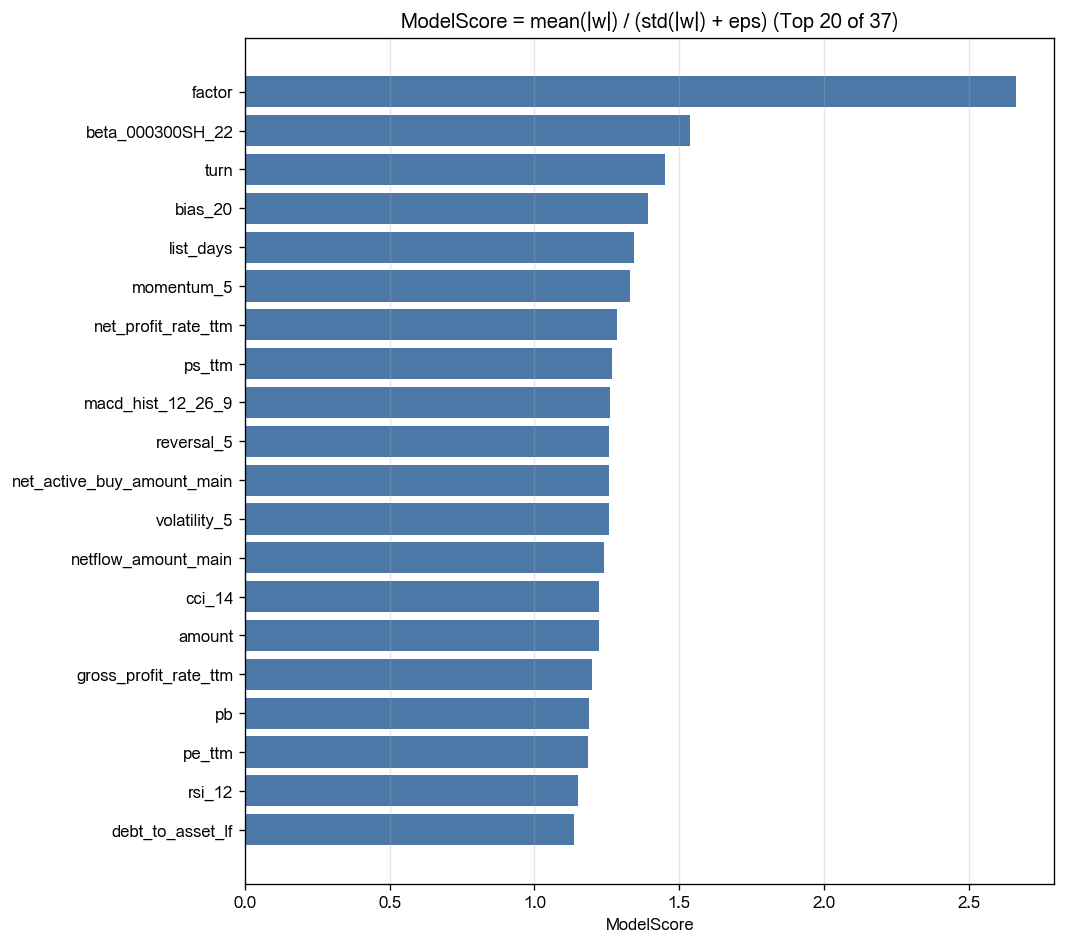
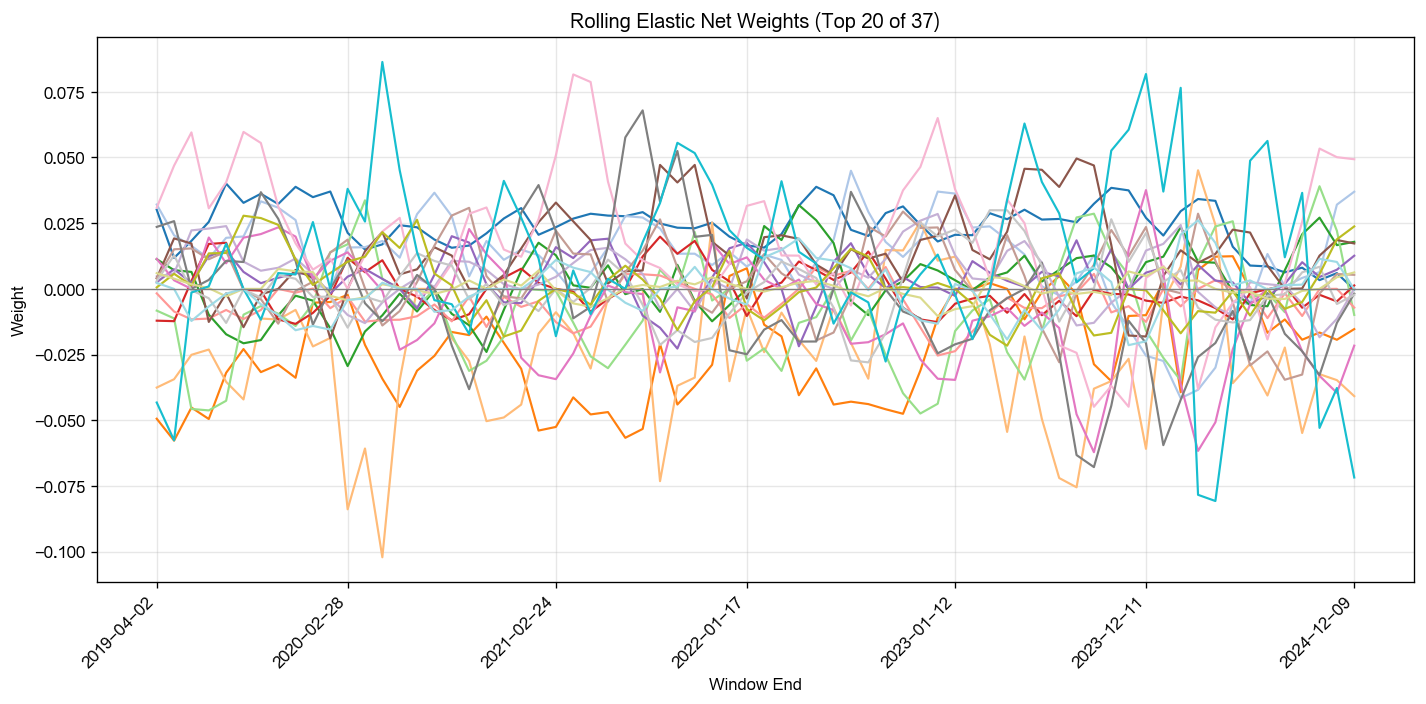
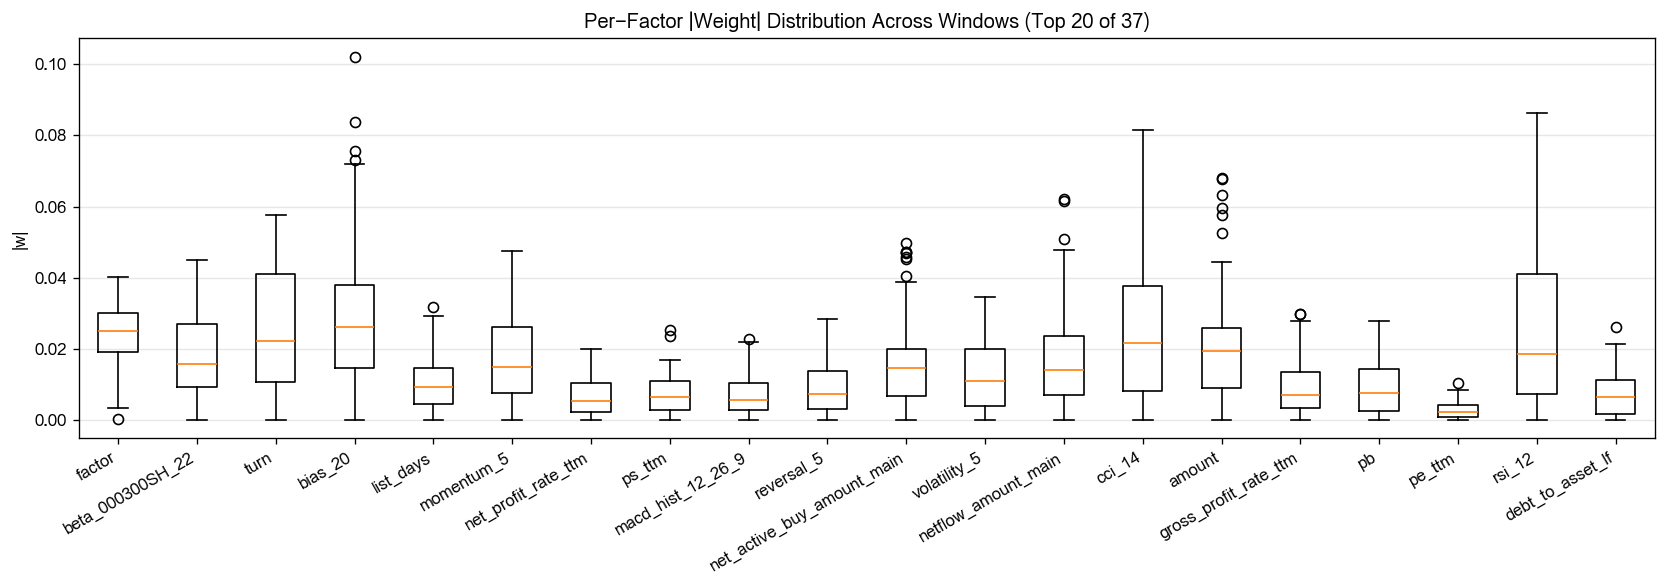
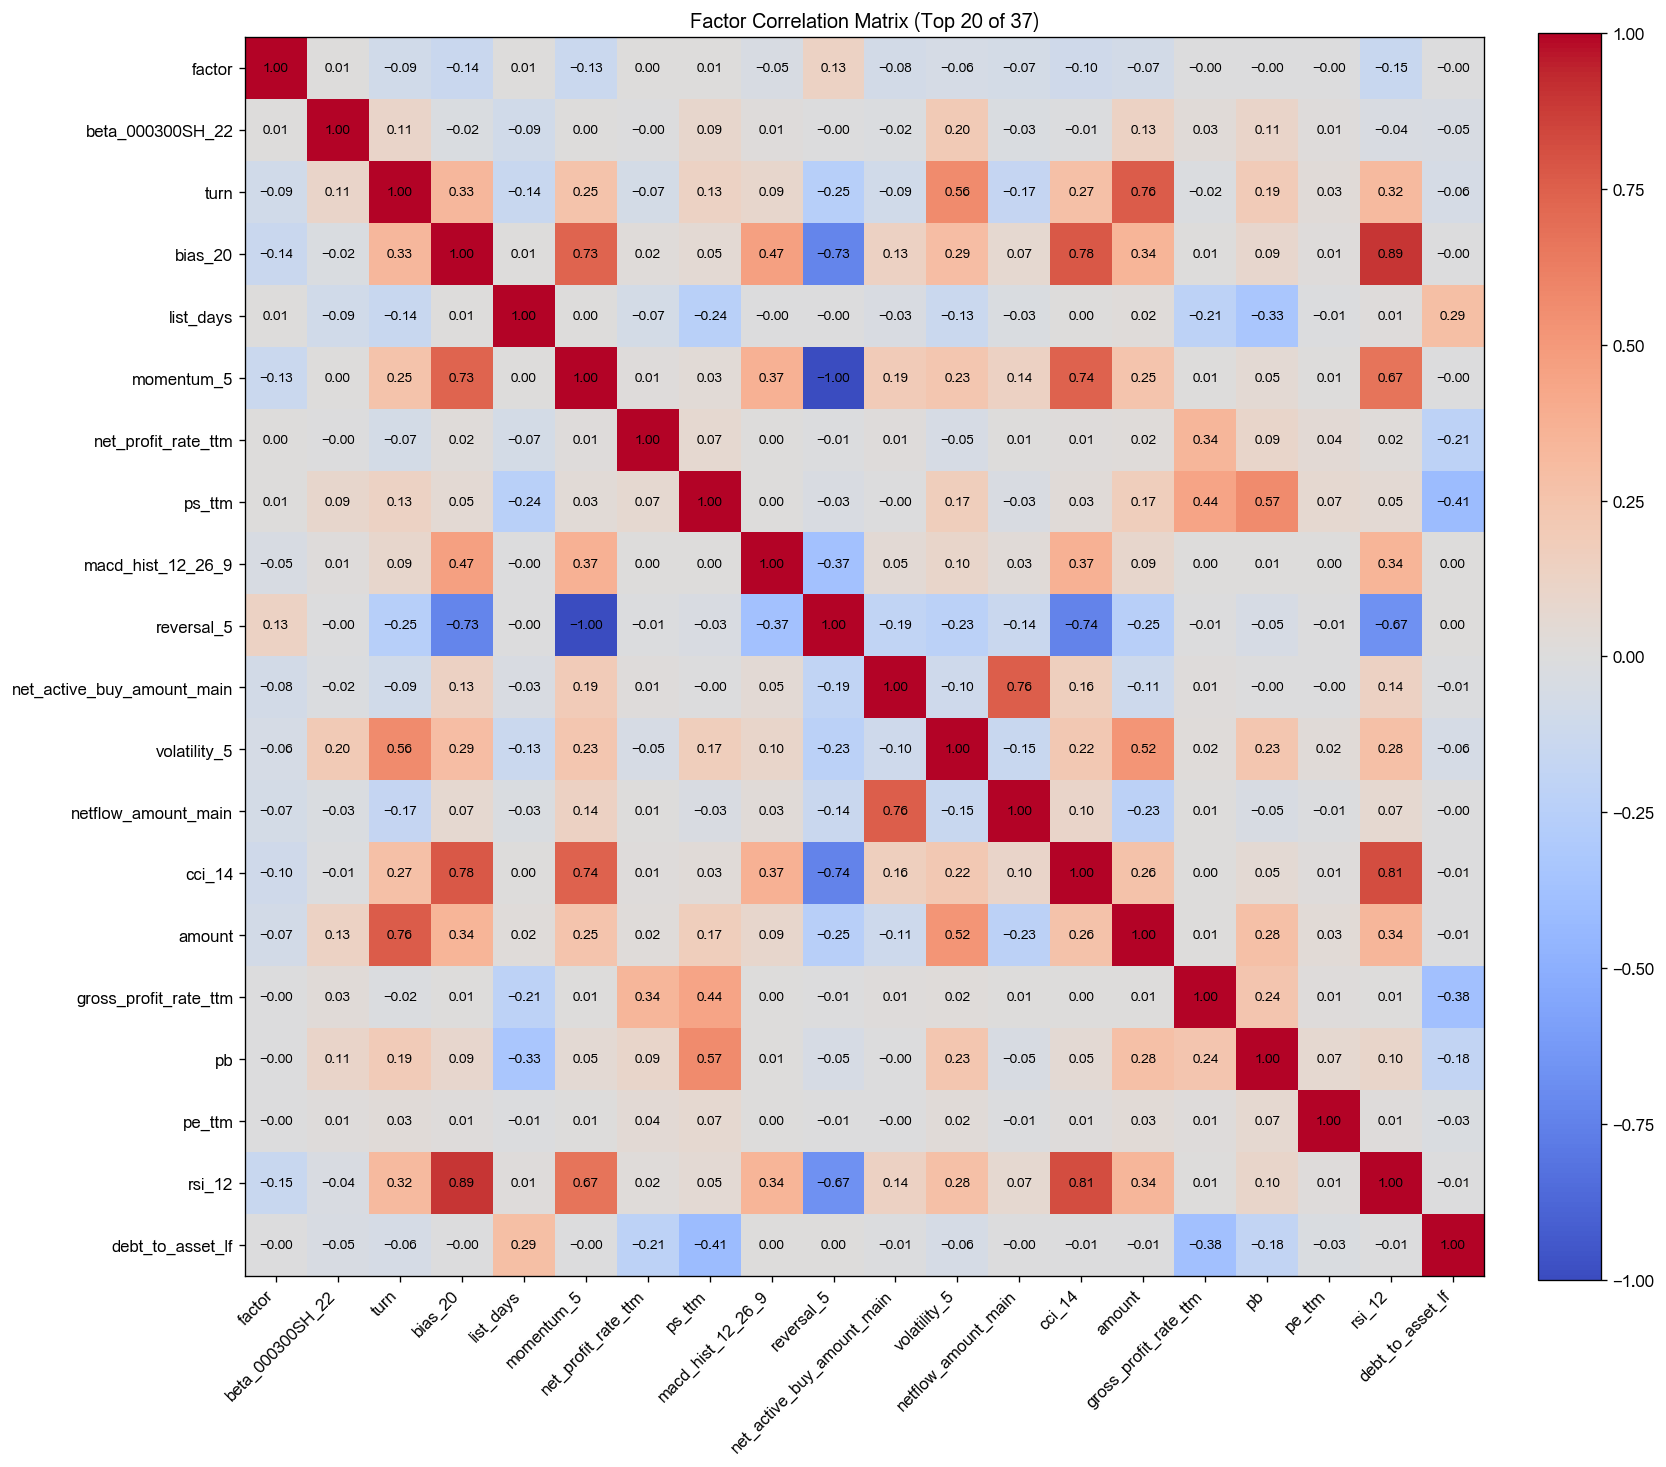

[2026-07-19 08:54:20] [warning  ] 返回的Outputs实例(size=213330512) 大于 64K, 将不会被缓存
[2026-07-19 08:54:20] [info     ] bigalpha_eval.v4 运行完成 [61.390s].


In [16]:
if __name__== "__main__":
    from bigquant import dai
    from bigmodule import M
    import structlog
    logger = structlog.get_logger()
    
    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2019-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"
    
    factor_data = main(datasources, start_date, end_date)
    logger.info("Factor computed", rows=len(factor_data))
    
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": ["2019-01-01", "2024-12-31"]},
    ).df()
    
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
